# **Comparación de modelos de regresión - Dataset Spotify 2023**
**Branco Merino Huerta - Ingeniería en Informática - 15 de mayo de 2026**


El objetivo de este trabajo es comparar distintos modelos de regresión para predecir la variable `streams` utilizando el dataset Spotify 2023.

Se entrenarán y evaluarán los siguientes modelos:

- Árbol de decisión para regresión
- Random Forest para regresión
- Modelo clásico de regresión (Ridge)

Además, se analizará el comportamiento de cada modelo utilizando distintas métricas de evaluación y gráficos comparativos.

# 1.0 Importación de librerías

In [1]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librería para dividir datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Herramientas de preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Modelos de regresión
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

# Métricas de evaluación
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# 2.0 Carga del Dataset

In [2]:
# Ruta del archivo Excel
# Cambia esta ruta si tu archivo está en otra carpeta
ruta_archivo = "spotify-2023-mod.xlsx"

# Leemos el archivo Excel y lo cargamos en un DataFrame
df = pd.read_excel(ruta_archivo)

## 2.1 Visualización inicial de los datos

In [3]:
#Mostramos las primeras 20 filas del dataset
df.head(20)

,track_name,released_year,released_month,released_day,in_spotify_playlists,streams,key,mode,danceability_%,energy_%
0,Seven (feat. Latto) (Explicit Ver.),2023,7,14,553.0,141381703,B,Major,80.0,83
1,LALA,2023,3,23,1474.0,133716286,C#,Major,71.0,74
2,vampire,2023,6,30,1397.0,140003974,F,Major,51.0,53
3,Cruel Summer,2019,8,23,7858.0,800840817,A,Major,55.0,72
4,WHERE SHE GOES,2023,5,18,3133.0,303236322,A,Minor,65.0,80
5,Sprinter,2023,6,1,2186.0,183706234,C#,Major,92.0,58
6,Ella Baila Sola,2023,3,16,3090.0,725980112,F,Minor,67.0,76
7,Columbia,2023,7,7,714.0,58149378,F,Major,67.0,71
8,fukumean,2023,5,15,NaN,95217315,C#,Minor,85.0,62
9,La Bebe - Remix,2023,3,17,NaN,553634067,D,NaN,NaN,48


# 3.0 Información general del dataset

Utilizamos `df.info()` para obtener un resumen rápido de nuestro Dataframe.

Esto nos permite:
- Identificar el número total de filas y columnas.
- Conocer el nombre y el tipo de dato de cada columna.
- Detectar la presencia de valores nulos, lo cual es crucial para la limpieza de datos.


In [4]:
#Iniciamos el resumen rápido
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 952 entries, 0 to 951
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            952 non-null    object 
 1   released_year         952 non-null    int64  
 2   released_month        952 non-null    int64  
 3   released_day          952 non-null    int64  
 4   in_spotify_playlists  905 non-null    float64
 5   streams               952 non-null    int64  
 6   key                   857 non-null    object 
 7   mode                  905 non-null    object 
 8   danceability_%        905 non-null    float64
 9   energy_%              952 non-null    int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 74.5+ KB


Posteriormente, utilizaremos `df.describe()` para generar un resumen estadístico de las variables numéricas del dataset. Este resumen incluye medidas de tendencia central, dispersión y posición, lo que nos permite comprender la distribución de los datos y detectar posibles anomalías.

In [5]:
#Iniciamos el resumen estadístico
df.describe()

,released_year,released_month,released_day,in_spotify_playlists,streams,danceability_%,energy_%
count,952.000000,952.000000,952.000000,905.000000,9.520000e+02,905.000000,952.000000
mean,2018.288866,6.038866,13.944328,5273.350276,5.141374e+08,66.981215,64.274160
std,11.011397,3.564571,9.197223,7991.359501,5.668569e+08,14.700953,16.558517
min,1930.000000,1.000000,1.000000,31.000000,2.762000e+03,23.000000,9.000000
25%,2020.000000,3.000000,6.000000,870.000000,1.416362e+08,57.000000,53.000000
50%,2022.000000,6.000000,13.000000,2224.000000,2.905309e+08,69.000000,66.000000
75%,2022.000000,9.000000,22.000000,5730.000000,6.738690e+08,78.000000,77.000000
max,2023.000000,12.000000,31.000000,52898.000000,3.703895e+09,96.000000,97.000000


## 3.1 Observaciones

**Hallazgos Principales:**

*   **Estructura y Calidad:** El dataset cuenta con 952 registros y 10 columnas, incluyendo variables numéricas y categóricas.

*   **Perfil Temporal:** La mayoría de los lanzamientos son recientes, con una mediana en el año 2022.
*   **Distribución y Sesgos:**

    *   **Alta Dispersión:** Las variables streams e in_spotify_playlists presentan una gran variabilidad, ya que sus valores máximos son considerablemente superiores a la mediana, sugiriendo la presencia de outliers.
    *   **Estabilidad:** Los atributos musicales (danceability_%, energy_%) muestran un comportamiento uniforme.


NOTA: La variable objetivo utilizada será `streams`, correspondiente a la cantidad de reproducciones de cada canción.

Las demás variables serán utilizadas como predictoras para entrenar los modelos de regresión.




# 4.0 Revisión de valores nulos

Comenzaremos identificando los valores nulos en el dataset para determinar en qué columnas se requiere imputación.

In [6]:
# Crear tabla resumen
resumen = pd.DataFrame({
    "Tipo de dato": df.dtypes,
    "Valores No Nulos": df.count(),
    "Cantidad nulos": df.isnull().sum(),
    "% nulos": (df.isnull().mean() * 100).round(2).astype(str) + '%',
    "Valores Únicos": df.nunique()
})

# Ordenar por cantidad de nulos para priorizar la limpieza
resumen = resumen.sort_values(by="Cantidad nulos", ascending=False)

# Mostrar tabla
print("Resumen de Calidad de Datos:")
resumen

Resumen de Calidad de Datos:


,Tipo de dato,Valores No Nulos,Cantidad nulos,% nulos,Valores Únicos
key,object,857,95,9.98%,11
in_spotify_playlists,float64,905,47,4.94%,835
mode,object,905,47,4.94%,2
danceability_%,float64,905,47,4.94%,72
released_year,int64,952,0,0.0%,50
track_name,object,952,0,0.0%,942
streams,int64,952,0,0.0%,948
released_day,int64,952,0,0.0%,31
released_month,int64,952,0,0.0%,12
energy_%,int64,952,0,0.0%,80


**Observación**

Se realizó una revisión de valores faltantes para identificar posibles problemas dentro del dataset.

Se observó que algunas variables presentan valores nulos.

Para evitar eliminar registros innecesariamente, los valores faltantes serán tratados mediante imputación:



*   Variables numéricas → mediana
*   Variables categóricas → valor más frecuente

La imputación será realizada dentro de pipelines de preprocesamiento para evitar data leakage.

Esto permite que los parámetros de imputación se calculen únicamente utilizando los datos de entrenamiento.

# 5.0 Revisión de Outliers

Esta etapa se enfoca en identificar la presencia de valores extremos y analizar su posible impacto sobre la distribución de los datos y las métricas estadísticas, puesto que estos registros pueden sesgar y afectar la interpretación de algunas métricas.


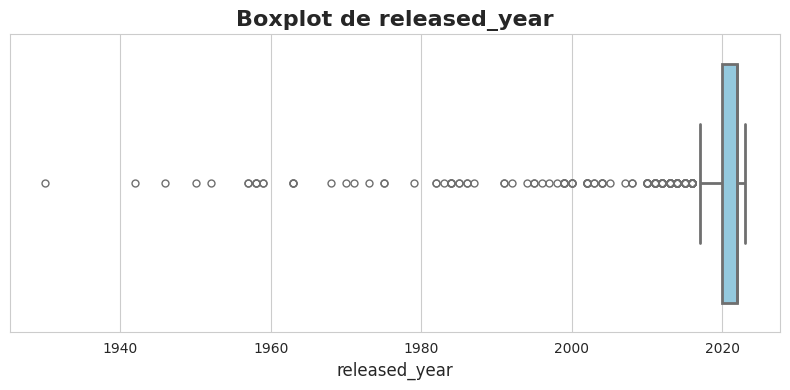

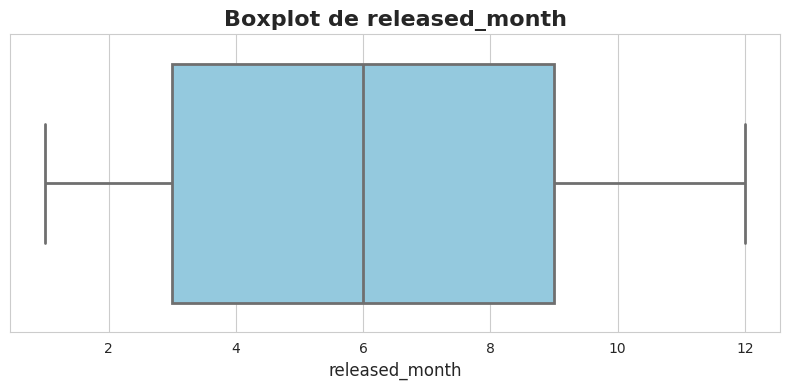

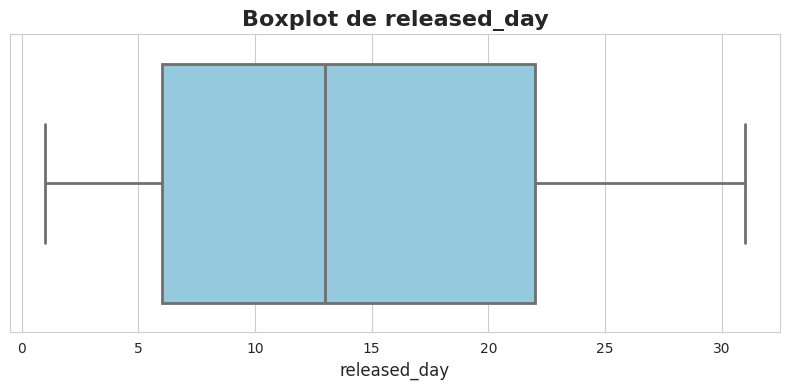

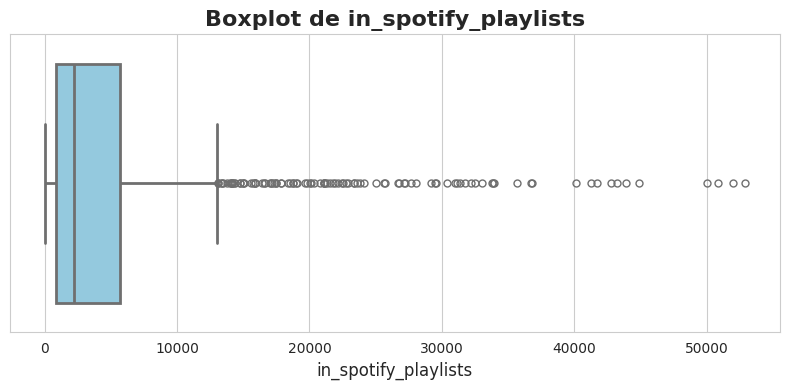

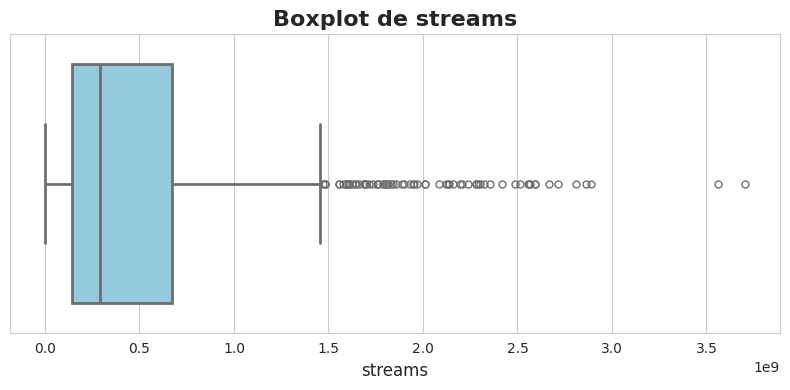

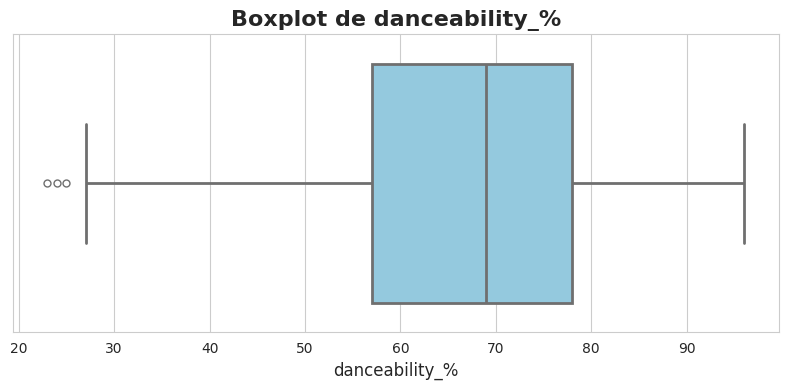

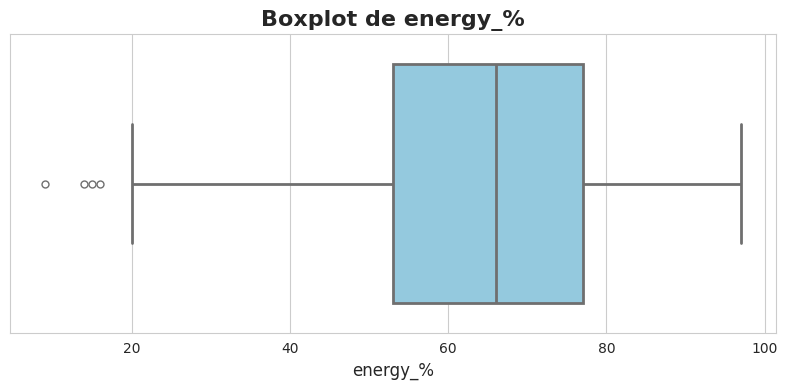

In [7]:
# Seleccionar variables numéricas
variables_numericas = df.select_dtypes(include=np.number).columns

# Estilo visual
sns.set_style("whitegrid")

# Crear un boxplot individual por variable
for columna in variables_numericas:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[columna],
        color="skyblue",
        linewidth=2,
        fliersize=5
    )

    plt.title(f"Boxplot de {columna}",
              fontsize=16,
              fontweight='bold')

    plt.xlabel(columna, fontsize=12)

    plt.tight_layout()
    plt.show()

**Observación:**

Se observan outliers en algunas variables numéricas, especialmente en la variable de streams.

Estos valores no serán eliminados debido a que representan comportamientos reales dentro de Spotify, donde algunas canciones alcanzan niveles de popularidad considerablemente superiores al promedio.

Eliminar estos valores podría afectar negativamente la capacidad predictiva de los modelos y reducir la representación real del problema.

# 6.0 Definición de variables predictoras y objetivo

La variable streams será utilizada como objetivo del modelo debido a que corresponde al valor que deseamos predecir.

Mientras que las demás variables del dataset serán utilizadas como variables predictoras.

In [8]:
# Eliminamos streams porque será la variable objetivo.
# También eliminamos track_name ya que:
# - Contiene demasiadas categorías únicas,
# - Aumenta excesivamente la dimensionalidad,
# - No aporta una relación clara para generalizar predicciones.

X = df.drop([
    "streams",
    "track_name"], axis=1)

# Variable objetivo
y = df["streams"]

# 7.0 Identificación de variables numéricas y categóricas

Separaremos las variables numéricas y categóricas para aplicar distintos tipos de preprocesamiento según corresponda.

Las variables categóricas requieren transformación a formato numérico (One Hot Encoding o Label Encoding) para poder ser utilizadas por los modelos de machine learning.

In [9]:
# Selecciona automáticamente todas las columnas númericas del Dataframe
variables_numericas = X.select_dtypes(include=np.number).columns

# Selecciona automáticamente todas las columnas NO númericas del Dataframe
variables_categoricas = X.select_dtypes(exclude=np.number).columns

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
Index(['released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'danceability_%', 'energy_%'],
      dtype='object')

Variables categóricas:
Index(['key', 'mode'], dtype='object')


# 8.0 Separación del dataset

El dataset será dividido en:

*   80% datos de entrenamiento
*   20% datos de prueba

Esto nos permite entrenar cada modelo utilizando solo una parte de los datos para posteriormente evaluar su desempeño con información que no fue visualizada durante el entrenamiento.

# Matriz de Correlación


In [10]:
# Divide los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,

# Se reserva el 20% de los datos para pruebas
# El 80% restante se utilizará para entrenar el modelo
    test_size=0.2,

# Fijar una semilla para que la división siempre sea igual
    random_state=42
)

print("Dimensiones entrenamiento:")
print(X_train.shape)

print("\nDimensiones prueba:")
print(X_test.shape)

Dimensiones entrenamiento:
(761, 8)

Dimensiones prueba:
(191, 8)


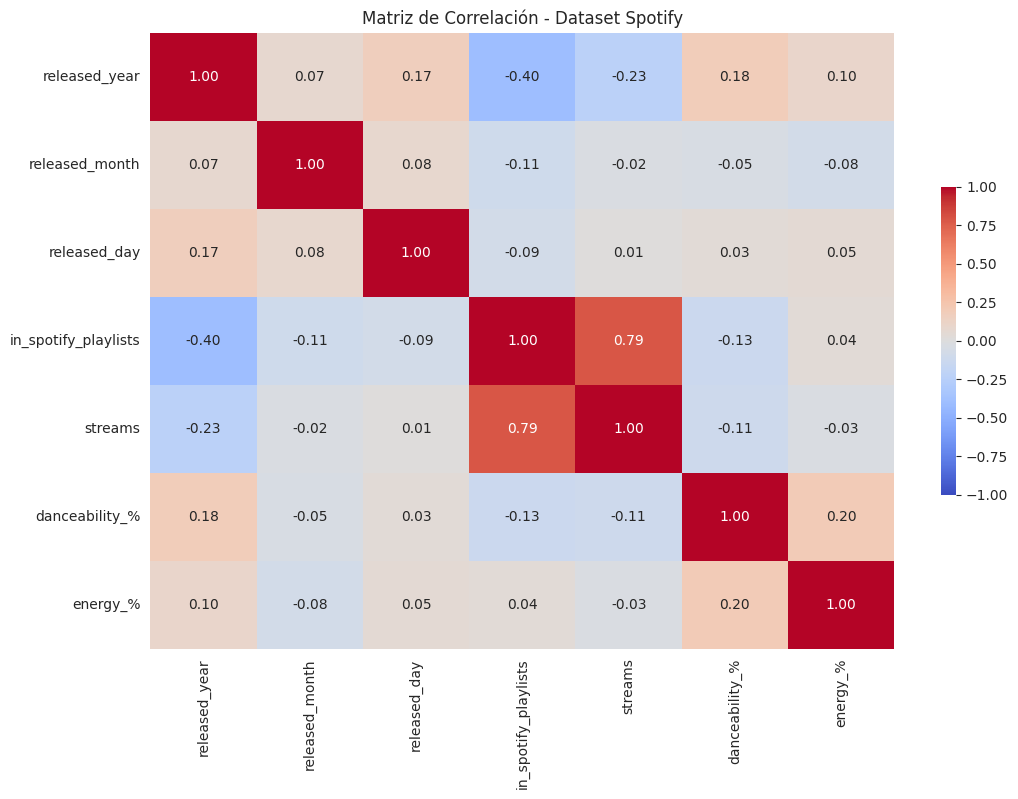

In [11]:
# Selecciona únicamente las columnasnuméricas del Dataframe y calcula correlación
correlacion = df.select_dtypes(include=np.number).corr()

# Definir el tamaño de la figura
plt.figure(figsize=(12,8))

# Detalles de la Matriz
sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0,
    cbar_kws={"shrink": .5}

)

plt.title("Matriz de Correlación - Dataset Spotify")

plt.show()

## Interpretación

La matriz de correlación muestra qué tan fuerte es la relación lineal entre las variables y los streams. La correlación más fuerte con streams corresponde a la variable in_spotify_playlists (0.79), lo que indica una correlación positiva fuerte: las canciones presentes en más playlists tienden a obtener más reproducciones, lo que sugiere que una mayor exposición dentro de Spotify influye directamente en la cantidad de reproducciones.

En contraste, variables musicales como danceability_% y energy_% presentan correlaciones cercanas a 0, indicando que estas características tienen poca influencia directa sobre la cantidad de streams. Del mismo modo, variables como released_day y released_month no muestran relaciones significativas con las reproducciones.

Por otro lado, released_year presenta una correlación negativa moderada con variables de exposición, lo que sugiere que las canciones más antiguas tienden a acumular mayor presencia en playlists y más reproducciones con el tiempo. Esto indica que la antigüedad de una canción puede influir en su alcance debido a la acumulación progresiva de audiencia y visibilidad dentro de Spotify.

# 9.0 Modelos

## 9.1 Modelo "Árbol de decisión para regresión"

Es un modelo de machine learning que se utiliza para predecir valores numéricos. Funciona realizando divisiones sucesivas mediante reglas o decisiones que separan observaciones con características similares.

En cada división, el modelo agrupa datos con valores similares para mejorar la predicción. Finalmente, el árbol entrega un valor numérico estimado, como por ejemplo la cantidad de streams de una canción. Su principal ventaja es que es fácil de interpretar y entender.

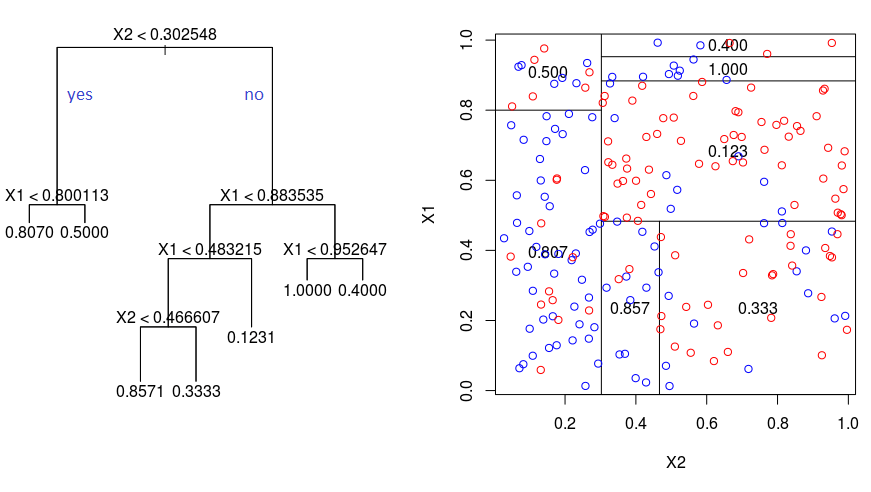

In [12]:
# Importar ilustración
from IPython.display import Image, display

display(Image('/content/ilus_arb_reg.png'))

## 9.2 Modelo "Random Forest para regresión"

Es un modelo de machine learning que utiliza múltiples árboles de decisión para realizar predicciones más precisas y estables. Cada árbol es entrenado utilizando diferentes subconjuntos de datos y variables aleatorias, lo que permite reducir la variabilidad del modelo.

En problemas de regresión, el resultado final se obtiene promediando las predicciones de todos los árboles.

Además, en este trabajo se configuraron hiperparámetros como `max_depth` y `min_samples_leaf` para limitar la complejidad de los árboles y reducir el riesgo de sobreajuste, mejorando así la capacidad de generalización del modelo.

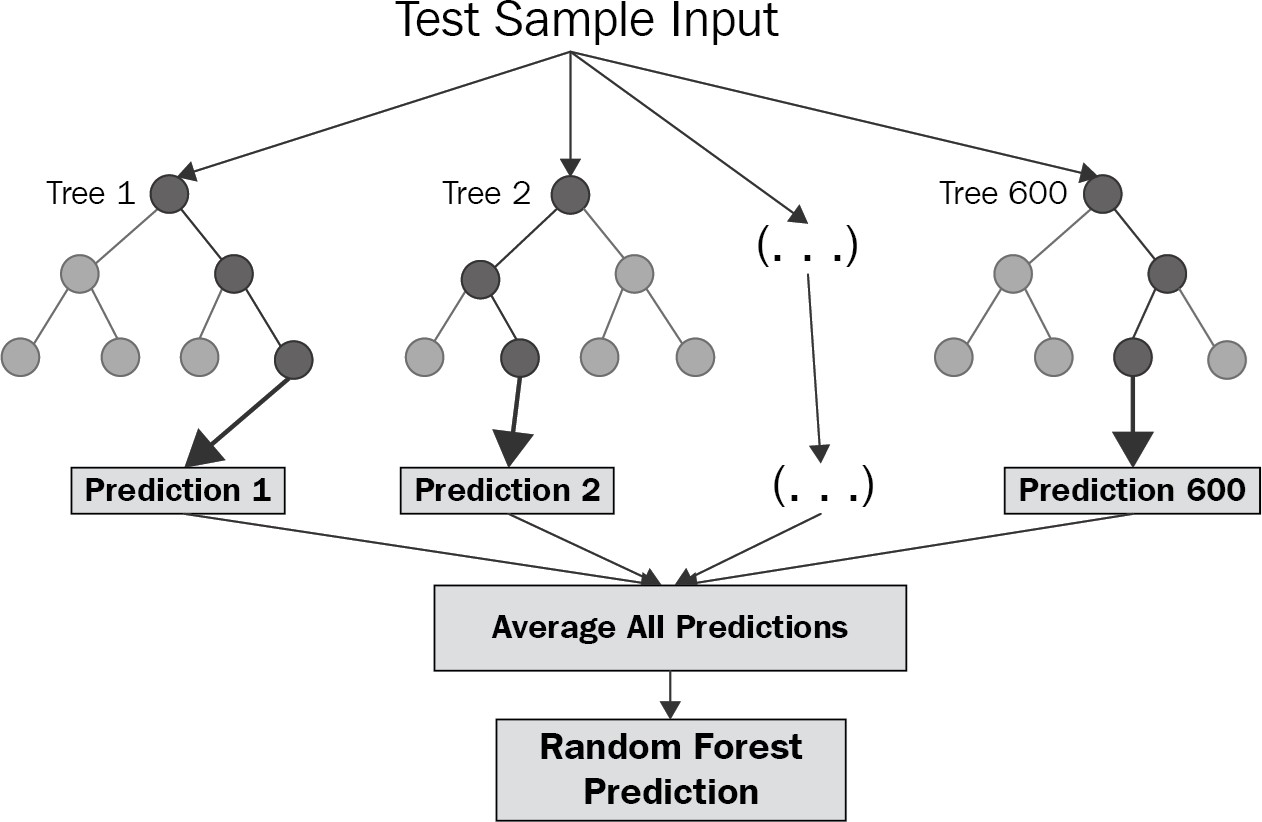

In [13]:
# Importar ilustración
from IPython.display import Image, display

display(Image('/content/ilus_rand_forest.png'))

## 9.3 Modelo "Ridge" para regresión

Es un modelo de regresión lineal que se utiliza para mejorar las predicciones cuando existen muchas variables o relaciones complejas entre ellas. Funciona de manera similar a una regresión lineal tradicional, pero agrega una penalización a los coeficientes del modelo para evitar que algunos tengan valores demasiado grandes.

Esto ayuda a reducir el overfitting y mejora la capacidad del modelo para generalizar con datos nuevos. En problemas como la predicción de streams, Ridge busca encontrar una relación equilibrada entre las variables y el valor a predecir.

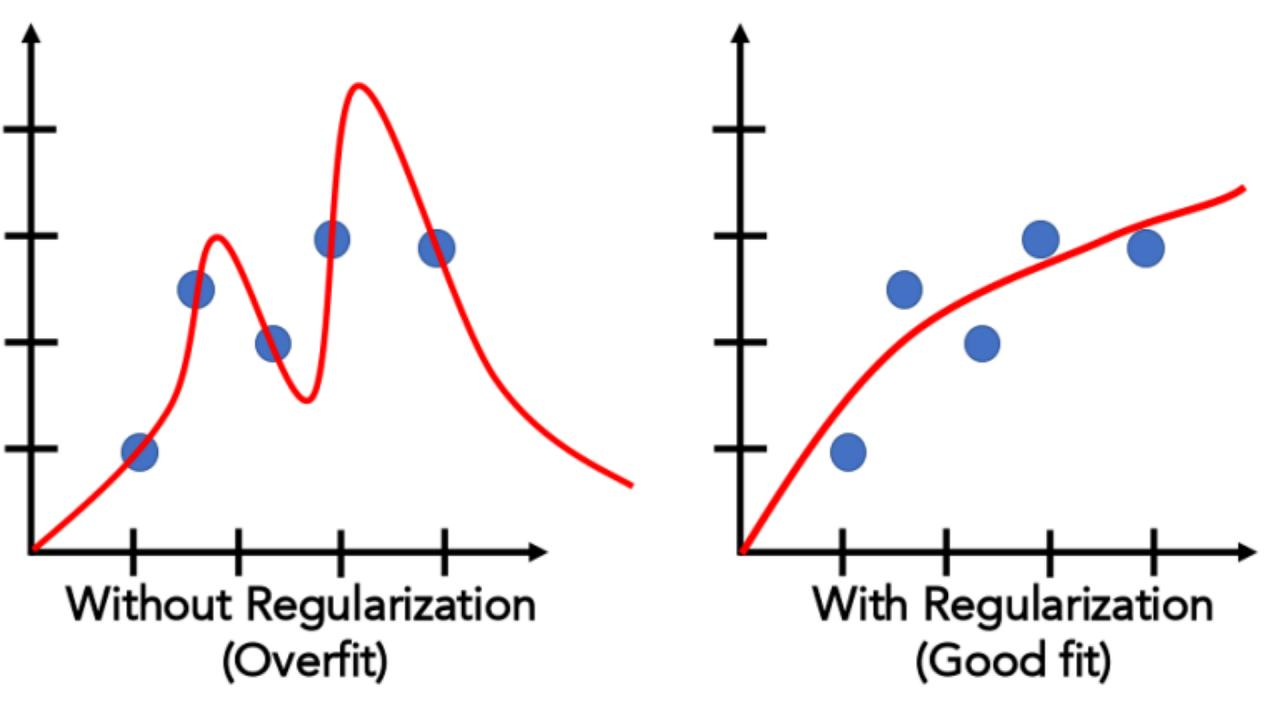

In [14]:
# Importar ilustración
from IPython.display import Image, display

display(Image('/content/ilus_ridge.jpg'))

### Preprocesamiento de Modelos

Preprocesamiento para modelos basados en árboles

In [15]:
# Aplica distintos procesos según el tipo de variable
preprocessor_tree = ColumnTransformer([

    (
        # Procesamiento para variables numéricas
        "num",

        # Rellena valores faltantes usando la mediana
        SimpleImputer(strategy="median"),
        variables_numericas
    ),

    (
        # Procesamiento para variables categóricas
        "cat",

        Pipeline([

            # Rellena valores vacíos con el valor más frecuente
            ("imputer", SimpleImputer(strategy="most_frequent")),

            # Convierte texto en valores numéricos
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),

        variables_categoricas
    )
])

Preprocesamiento Ridge

In [16]:
# Aplica distintos procesos según el tipo de variable
preprocessor_ridge = ColumnTransformer([

    (
        # Procesamiento para variables numéricas
        "num",

        Pipeline([

            # Rellena valores faltantes con la mediana
            ("imputer", SimpleImputer(strategy="median")),

            # Escala los datos para que tengan valores similares
            ("scaler", StandardScaler())
        ]),

        variables_numericas
    ),

    (
        # Procesamiento para variables categóricas
        "cat",

        Pipeline([

            # Rellena valores faltantes con el valor más frecuente
            ("imputer", SimpleImputer(strategy="most_frequent")),

            # Convierte texto en variables numéricas
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]),

        variables_categoricas
    )
])

**Observación:**

En Ridge es necesario usar StandardScaler porque el modelo penaliza los coeficientes y las variables con escalas grandes podrían influir más en el resultado. El escalado evita que variables con valores más grandes tengan una influencia desproporcionada sobre el modelo.

En cambio, los árboles de decisión y Random Forest no necesitan escalado, ya que funcionan mediante comparaciones entre valores y su rendimiento no depende de la escala de las variables.

## 9.4 Modelo Árbol de decisión

In [17]:
# Crea un pipeline para ejecutar el preprocesamiento y el modelo automáticamente
modelo_tree = Pipeline([

    # Primero prepara los datos
    ("preprocessor", preprocessor_tree),

    # Luego entrena el árbol de decisión
    ("model", DecisionTreeRegressor(
        random_state=42
    ))
])

# Entrena el modelo usando los datos de entrenamiento
modelo_tree.fit(X_train, y_train)

# Realiza predicciones usando los datos de prueba
pred_tree = modelo_tree.predict(X_test)

## 9.5 Modelo Random Forest

In [18]:
# Crea un pipeline para ejecutar el preprocesamiento y el modelo automáticamente
modelo_rf = Pipeline([

    # Primero prepara los datos
    ("preprocessor", preprocessor_tree),

    # Modelo Random Forest
    ("model", RandomForestRegressor(

        # Cantidad de árboles que se crearán
        n_estimators=100,

        # Profundidad máxima de cada árbol
        max_depth=10,

        # Cantidad mínima de datos por hoja
        min_samples_leaf=5,

        # Mantiene resultados reproducibles
        random_state=42
    ))
])

# Entrena el modelo usando los datos de entrenamiento
modelo_rf.fit(X_train, y_train)

# Realiza predicciones usando los datos de prueba
pred_rf = modelo_rf.predict(X_test)

## 9.6 Modelo Ridge

In [19]:
# Crea un pipeline para ejecutar el preprocesamiento y el modelo automáticamente
modelo_ridge = Pipeline([

    # Primero prepara los datos
    ("preprocessor", preprocessor_ridge),

    # Modelo de regresión Ridge
    ("model", Ridge())
])

# Entrena el modelo usando los datos de entrenamiento
modelo_ridge.fit(X_train, y_train)

# Realiza predicciones usando los datos de prueba
pred_ridge = modelo_ridge.predict(X_test)

# 10.0 Evaluar métricas

In [20]:
# Función para calcular métricas de evaluación
def evaluar_modelo(y_real, y_pred):

    r2 = r2_score(y_real, y_pred)

    mse = mean_squared_error(y_real, y_pred)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y_real, y_pred)

    # Devuelve todas las métricas en una lista
    return [r2, mse, rmse, mae]

## 10.1 Tabla comparativa de métricas

In [21]:
# Crea un DataFrame para guardar los resultados de cada modelo
resultados = pd.DataFrame({

    # Nombre de los modelos evaluados
    "Modelo": [
        "Decision Tree",
        "Random Forest",
        "Ridge"
    ],

    # Guarda el R² de cada modelo
    "R2": [

        evaluar_modelo(y_test, pred_tree)[0],

        evaluar_modelo(y_test, pred_rf)[0],

        evaluar_modelo(y_test, pred_ridge)[0]
    ],

    # Guarda el MSE de cada modelo
    "MSE": [

        evaluar_modelo(y_test, pred_tree)[1],

        evaluar_modelo(y_test, pred_rf)[1],

        evaluar_modelo(y_test, pred_ridge)[1]
    ],

    # Guarda el RMSE de cada modelo
    "RMSE": [

        evaluar_modelo(y_test, pred_tree)[2],

        evaluar_modelo(y_test, pred_rf)[2],

        evaluar_modelo(y_test, pred_ridge)[2]
    ],

    # Guarda el MAE de cada modelo
    "MAE": [

        evaluar_modelo(y_test, pred_tree)[3],

        evaluar_modelo(y_test, pred_rf)[3],

        evaluar_modelo(y_test, pred_ridge)[3]
    ]
})

resultados = resultados.round(2)

# Muestra la tabla final
resultados

,Modelo,R2,MSE,RMSE,MAE
0,Decision Tree,0.59,1.005013e+17,3.170193e+08,1.992985e+08
1,Random Forest,0.76,5.884884e+16,2.425878e+08,1.644700e+08
2,Ridge,0.53,1.143709e+17,3.381877e+08,2.331297e+08


## 10.2 Gráficos

### 10.2.1 Gráfico Árbol de decisión

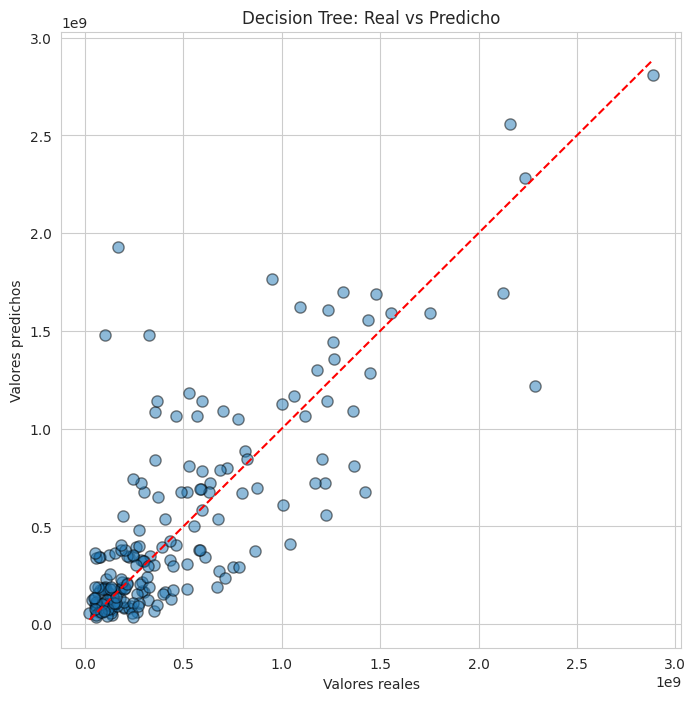

In [22]:
# Define el tamaño del gráfico
plt.figure(figsize=(8,8))

# Crea un gráfico de dispersión
plt.scatter(
    y_test,
    pred_tree,
    alpha=0.5,
    edgecolor="black",
    s=65
)

# Dibuja la línea ideal de predicción
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

# Nombre del eje X
plt.xlabel("Valores reales")

# Nombre del eje Y
plt.ylabel("Valores predichos")

# Título del gráfico
plt.title("Decision Tree: Real vs Predicho")

# Muestra el gráfico
plt.show()

**OBSERVACIÓN:**

El gráfico muestra que existe una relación entre los valores reales y predichos, ya que cuando aumentan los streams reales, las predicciones también tienden a aumentar.

Aun así, varios puntos se encuentran alejados de la línea ideal, lo que refleja que el modelo presenta errores importantes en algunas predicciones y una menor precisión en canciones con muchos streams.

### 10.2.2 Gráfico Random Forest

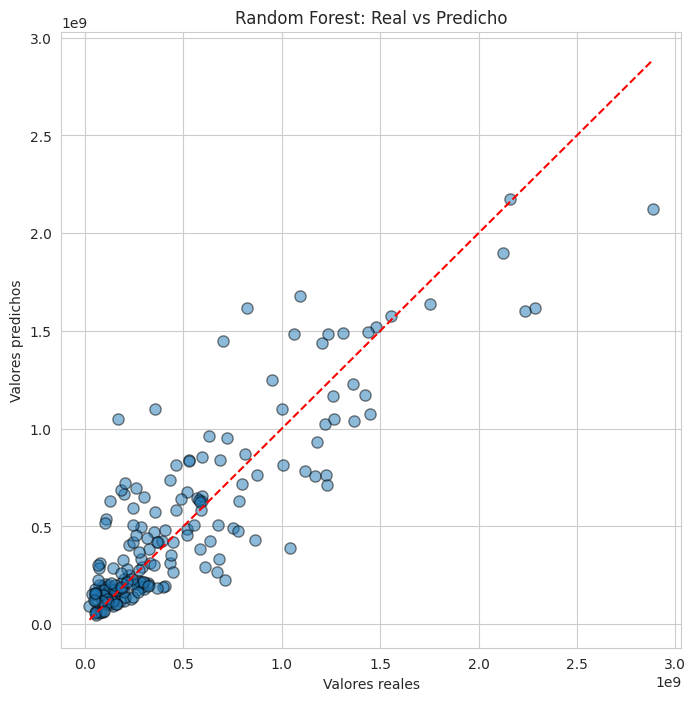

In [23]:
# Define el tamaño del gráfico
plt.figure(figsize=(8,8))

# Crea un gráfico de dispersión
plt.scatter(
    y_test,
    pred_rf,
    alpha=0.5,
    edgecolor="black",
    s=65
)

# Dibuja la línea ideal de predicción
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

# Nombre del eje X
plt.xlabel("Valores reales")

# Nombre del eje Y
plt.ylabel("Valores predichos")

# Título del gráfico
plt.title("Random Forest: Real vs Predicho")

# Muestra el gráfico
plt.show()

**OBSERVACIÓN:**

En el gráfico se observa que la mayoría de los puntos se encuentran relativamente cerca de la línea diagonal roja, lo que indica que las predicciones del modelo son bastante similares a los valores reales.

Esto indica que las predicciones siguen de manera adecuada el comportamiento general de los streams. Sin embargo, en canciones con streams muy altos todavía existe cierta dispersión, lo que indica algunos errores en casos extremos

### 10.2.3 Gráfico Ridge

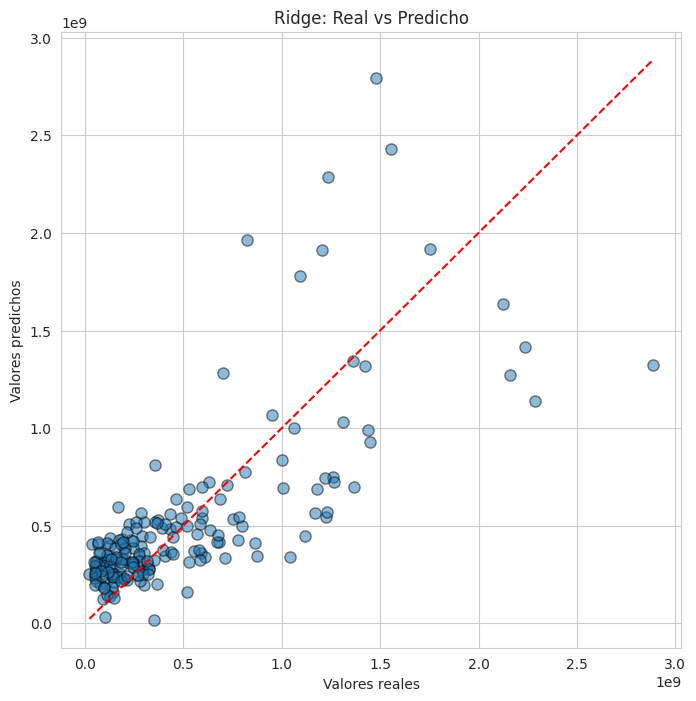

In [24]:
# Define el tamaño del gráfico
plt.figure(figsize=(8,8))

# Crea un gráfico de dispersión
plt.scatter(
    y_test,
    pred_ridge,
    alpha=0.5,
    edgecolor="black",
    s=65
)

# Dibuja la línea ideal de predicción
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

# Nombre del eje X
plt.xlabel("Valores reales")

# Nombre del eje Y
plt.ylabel("Valores predichos")

# Título del gráfico
plt.title("Ridge: Real vs Predicho")

# Muestra el gráfico
plt.show()

**OBSERVACIÓN**:

En este gráfico se aprecia que el modelo logra seguir parcialmente la tendencia general de los datos, pero muchos puntos se encuentran bastante alejados de la línea diagonal.

Esto indica que las predicciones no coinciden con tanta precisión con los valores reales, especialmente en canciones con niveles altos de reproducciones, donde el modelo presenta mayores dificultades para ajustarse a canciones con muchos streams.

## 10.3  Evaluación de Overfitting e Underfitting
Para analizar la capacidad de generalización de los modelos, se comparó el R² obtenido en entrenamiento y prueba.



In [25]:
overfitting = pd.DataFrame({

    "Modelo": [
        "Decision Tree",
        "Random Forest",
        "Ridge"
    ],

    "R2 Train": [
        modelo_tree.score(X_train, y_train),
        modelo_rf.score(X_train, y_train),
        modelo_ridge.score(X_train, y_train)
    ],

    "R2 Test": [
        modelo_tree.score(X_test, y_test),
        modelo_rf.score(X_test, y_test),
        modelo_ridge.score(X_test, y_test)
    ]
})

overfitting

,Modelo,R2 Train,R2 Test
0,Decision Tree,1.000000,0.589444
1,Random Forest,0.889759,0.759597
2,Ridge,0.624625,0.532785


**Interpretación:**

El modelo Decision Tree presentó un claro caso de overfitting, ya que obtuvo un R² de 1.00 en entrenamiento y solo 0.59 en prueba. Esto indica que el modelo memorizó demasiado los datos de entrenamiento y perdió capacidad de generalización.

Por otro lado, Random Forest obtuvo un R² de 0.89 en entrenamiento y 0.76 en prueba. Aunque existe cierto nivel de overfitting, la diferencia entre ambos resultados es moderada, lo que demuestra una buena capacidad de generalización.

Finalmente, Ridge obtuvo un R² de 0.62 en entrenamiento y 0.53 en prueba. La diferencia entre ambos valores es pequeña, lo que indica poco overfitting, pero también evidencia underfitting, ya que el modelo no logra capturar correctamente la complejidad de los datos.

En general, Random Forest fue el modelo con mejor equilibrio entre precisión y generalización.

# 11.0 Interpretación de resultados

## ¿Cuál de los modelos se desempeñó mejor?

El modelo que obtuvo mejores resultados fue Random Forest. Alcanzó el R² más alto (0.76) y además presentó los errores más bajos en todas las métricas evaluadas.

Esto significa que fue el modelo con mejor capacidad para predecir la cantidad de streams de las canciones. El Árbol de Decisión tuvo un rendimiento aceptable, mientras que Ridge fue el modelo más débil de los tres.

---

### ¿Las diferencias entre modelos fueron grandes o pequeñas?

Las diferencias fueron bastante notorias, especialmente entre Random Forest y Ridge.

Random Forest mejoró considerablemente respecto al Árbol de Decisión:
- el R² subió de 0.59 a 0.76;
- el RMSE bajó de 317 millones a 242 millones;
- y el MAE disminuyó de 199 millones a 164 millones.

En comparación con Ridge, las diferencias fueron aún más claras. Esto demuestra que Random Forest logró adaptarse mucho mejor a los patrones del dataset.

---

### ¿Qué significa el valor de R² en este contexto?

El R² indica qué porcentaje de la variación de streams puede explicar el modelo.

En este caso:
- Random Forest explica cerca del 76% de la variabilidad;
- el Árbol de Decisión alrededor del 59%;
- y Ridge aproximadamente el 53%.

Considerando que el éxito de una canción depende también de factores externos que no aparecen en el dataset, como marketing, viralidad o fama del artista, un R² de 0.76 es un resultado bastante bueno.

---

## ¿Qué indican RMSE, MSE y MAE respecto al error de predicción?

Estas métricas permiten cuantificar el nivel de error entre las predicciones y los valores reales.

- MSE penaliza más los errores grandes.
- RMSE muestra el error promedio en la misma escala de streams.
- MAE indica cuánto se equivoca el modelo en promedio.

Por ejemplo, el Random Forest tuvo un MAE cercano a 166 millones de streams, lo que significa que normalmente el modelo se equivoca en esa cantidad de reproducciones por canción.

Aunque parecen errores altos, esto tiene sentido considerando que el dataset contiene canciones con miles de millones de reproducciones y una distribución muy desigual.

---

## ¿Cómo se compara el Árbol de Decisión con Random Forest?

El Árbol de Decisión obtuvo resultados inferiores al Random Forest porque un árbol individual tiende a sobreajustarse más fácilmente.

Además de combinar múltiples árboles, el modelo Random Forest fue configurado con restricciones de complejidad (max_depth y min_samples_leaf) para reducir el sobreajuste y mejorar la capacidad de generalización sobre datos no vistos.

Por eso logró métricas bastante mejores y predicciones más precisas.

---

## ¿Cómo se comportó Ridge frente a los otros modelos?

Ridge fue el modelo con peor desempeño general.

Esto sugiere que la relación entre las variables y streams no es completamente lineal. Aunque Ridge ayuda a controlar el sobreajuste y se aplicó StandardScaler correctamente, igualmente tuvo dificultades para capturar patrones complejos presentes en los datos.

Los modelos basados en árboles lograron adaptarse mucho mejor al comportamiento real del dataset.

---

## ¿Cómo influyeron las decisiones de preparación de datos?

Las decisiones de preprocesamiento influyeron bastante en el resultado final.

La imputación con mediana ayudó a manejar los valores faltantes sin verse afectada por los outliers. Además, el uso de OneHotEncoder permitió trabajar correctamente las variables categóricas.

También fue importante mantener los outliers, ya que representan canciones realmente populares y forman parte natural del problema.

Por otro lado, eliminar la variable `track_name` ayudó a evitar tener demasiadas categorías y posibles problemas de sobreajuste.

Finalmente, usar pipelines permitió evitar data leakage, asegurando que tanto la imputación como el escalado se ajustaran solo con los datos de entrenamiento.

# 12.0 Conclusión

Al comparar los distintos modelos de regresión, se observó que los métodos basados en árboles mostraron un mejor desempeño en la predicción de streams que el modelo lineal Ridge. Random Forest fue el modelo más sólido, logrando las predicciones más precisas y estables gracias a la combinación de múltiples árboles.

Además, se comprobó que las decisiones de preparación de datos influyen directamente en el rendimiento de los modelos, especialmente el manejo de los valores nulos, variables categóricas y outliers.

En este trabajo, Random Forest fue el modelo con mejor desempeño general, logrando la mayor capacidad predictiva y el menor error entre los modelos evaluados

Aun así, la predicción de streams sigue siendo un problema complejo, debido a que existen factores externos que no están incluidos en el dataset, como lo pueden ser las estrategias de marketing, viralidad en redes sociales (Tik Tok, Instagram), tendencias musicales o popularidad de los artistas.